<a href="https://colab.research.google.com/github/Roberto50p/Notebook_fraude_financiero/blob/main/Ev1_fraude_financiero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Subir datos

# Subir Datos
## link dataset
https://www.kaggle.com/datasets/mohamedasak/enterprise-fraud-detection-dataset


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving enterprise_fraud_dataset.csv to enterprise_fraud_dataset (1).csv


In [ ]:
uploaded.head()

AttributeError: 'dict' object has no attribute 'head'

In [ ]:
# Armando el dataset
for key in uploaded.keys():
  fileName = key
  print(fileName)

df = pd.read_csv(fileName, sep=",")

enterprise_fraud_dataset (1).csv


In [ ]:
# OPCIONAL
# cambio de configuración para mostrar todas las lineas y todas las columnas
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999

In [ ]:
df.head(10)

,transaction_id,customer_id,merchant_id,timestamp,hour,day,weekday,is_weekend,is_night,customer_segment,avg_spend_profile,home_lat,home_lon,past_fraud_history,credit_score,account_age_days,merchant_category,merchant_risk_score,merchant_lat,merchant_lon,transaction_amount,txn_lat,txn_lon,distance_from_home_km,is_foreign,high_risk_country,device_type,channel,is_new_device,vpn_detected,tor_detected,device_id,transaction_velocity_1h,transaction_velocity_24h,transaction_velocity_7d,seconds_since_last_txn,avg_amount_30d,amount_deviation_ratio,merchant_ring_id,shared_device_count,customer_merchant_txn_count,label,fraud_type,financial_loss
0,TXN00036139,9802,1487,2025-01-22 14:02:41.154565663,14,22,2,0,0,regular,363.036636,28.993915,25.727304,0,528,698,electronics,0.258955,30.551510,25.335166,424.75,27.962036,26.932768,163.760000,0,1,mobile_android,pos,0,0,0,d9191d2bfe8f,0,4,20,5.035833e+05,426.455356,0.9937,-1,0,4,0,legit,0.00
1,TXN00080533,9762,1412,2025-02-18 01:53:25.069276265,1,49,1,0,1,regular,341.886263,29.992794,33.324483,0,512,1604,food,0.168165,23.177659,29.313944,81.54,31.799389,31.348758,276.210000,0,0,unknown,atm,0,0,0,2dbad4502ef5,2,2,16,1.607163e+06,298.932645,0.2719,-1,0,1,0,legit,0.00
2,TXN00104222,9230,1690,2025-03-04 00:29:01.950036691,0,63,1,0,1,regular,606.779907,27.761604,36.593689,0,739,2244,grocery,0.173804,30.086739,24.234094,346.67,27.143286,38.223207,174.150000,0,0,mobile_android,online,0,0,0,6edfbc1505e6,2,2,17,1.702030e+05,502.709227,0.6882,-1,2,1,0,legit,0.00
3,TXN00154470,6009,942,2025-04-02 21:41:53.035782236,21,92,2,0,0,regular,317.343699,27.418521,26.506580,0,615,1790,crypto,0.578059,31.075309,31.140406,260.79,28.152342,24.986385,170.500000,0,0,mobile_ios,atm,1,0,0,d398daf2ac77,2,8,17,1.076657e+04,320.324984,0.8116,13,0,3,0,legit,0.00
4,TXN00079799,2818,715,2025-02-17 14:30:54.154685560,14,48,0,0,0,regular,168.961693,29.070841,29.386895,0,676,1872,retail,0.171036,27.310583,24.821893,143.13,27.606072,27.726742,228.860000,0,1,tablet_android,atm,0,0,0,3320d35130db,1,5,14,2.087674e+06,183.407743,0.7762,13,1,4,0,legit,0.00
5,TXN00008368,2614,1081,2025-01-05 23:29:35.565764832,23,5,6,1,0,regular,89.576650,22.411764,28.432325,0,622,3862,luxury,0.278529,27.564579,32.950031,99.07,18.115932,31.339959,562.490000,1,0,mobile_ios,in_app,0,0,0,dd47b62775b5,5,3,13,2.371139e+05,91.333901,1.0730,-1,0,5,0,legit,0.00
6,TXN00124297,10696,1284,2025-03-15 22:08:54.190990489,22,74,5,1,0,regular,212.002396,23.054714,26.745139,0,719,1516,retail,0.102414,25.126780,36.490815,211.77,25.800033,24.509366,380.790000,1,0,mobile_android,in_app,1,0,0,b53c8daeeb93,1,7,20,9.999900e+04,192.954738,1.0919,-1,0,3,0,legit,0.00
7,TXN00093609,11840,547,2025-02-25 18:49:43.598663158,18,56,1,0,0,new,1314.703342,22.397222,26.058475,1,850,967,retail,0.174748,25.297641,32.850571,1613.92,20.237300,27.843238,301.710000,1,0,desktop_firefox,online,0,0,0,d5265f194de9,2,5,17,1.395539e+05,1308.189924,1.2328,-1,0,7,0,legit,0.00
8,TXN00094219,8138,1429,2025-02-26 03:04:38.743591396,3,57,2,0,1,regular,304.105694,24.352270,30.485874,0,682,3809,retail,0.065736,29.601346,36.251044,364.36,21.069705,32.903033,438.760000,1,0,mobile_ios,in_app,0,0,0,763a2a71c7f2,1,3,25,2.629721e+05,265.007913,1.3697,-1,0,3,0,legit,0.00
9,TXN00059521,11956,1392,2025-02-05 11:54:02.662681150,11,36,2,0,0,regular,30.483139,30.664539,33.038190,0,643,2593,food,0.060665,25.089787,37.258143,101.98,34.244867,36.227473,4655.754696,1,1,desktop_chrome,atm,1,0,0,f74fdbffdb21,1,6,17,1.054913e+06,29.291008,3.3667,-1,0,3,1,identity_theft,101.98


In [ ]:
# Cantidad de filas y columnas
df.shape

(200000, 44)

In [ ]:
# comprobar si existe algun nulo
df.isnull().any().any()

# Si resulta en true exista almenos UN dato nulo

np.False_

In [ ]:
# Cantidad de nulos por columna
df.isnull().sum()

,0
transaction_id,0
customer_id,0
merchant_id,0
timestamp,0
hour,0
day,0
weekday,0
is_weekend,0
is_night,0
customer_segment,0


# Tabla de correlación

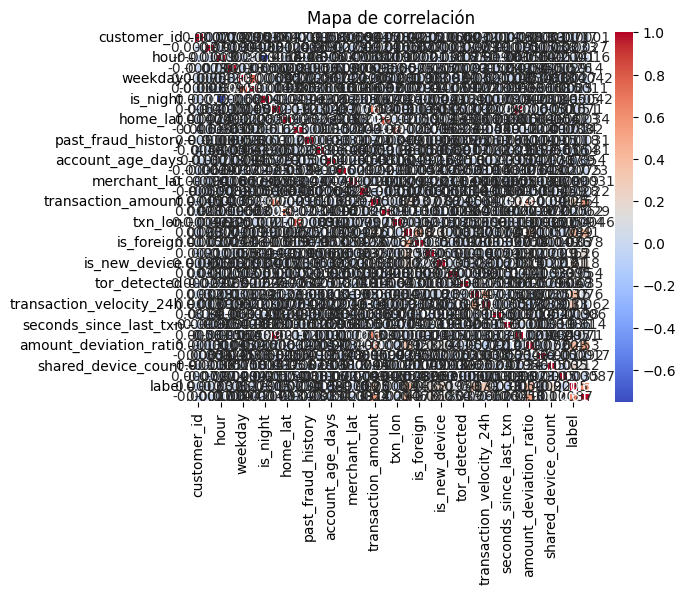

In [ ]:
corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", linewidth=0.5)
plt.title("Mapa de correlación")
plt.show()

In [ ]:
# Gráfico de la variable objetivo
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Target')
plt.title('Distribución de la variable objetivo')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

In [ ]:
df['label'].value_counts()

,count
label,
0,194437
1,5563


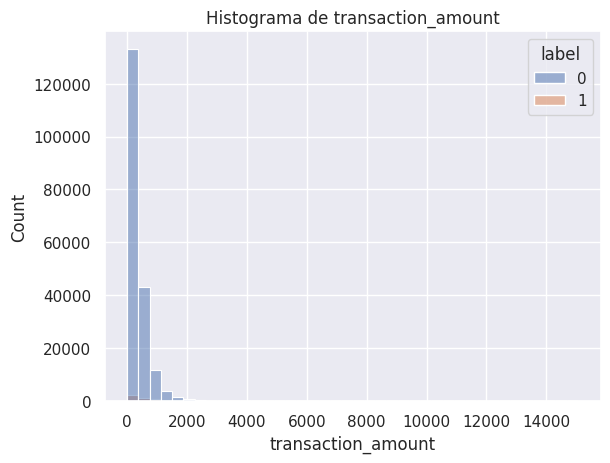

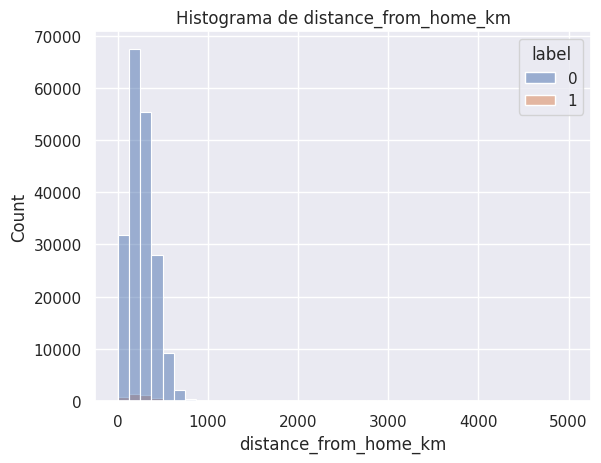

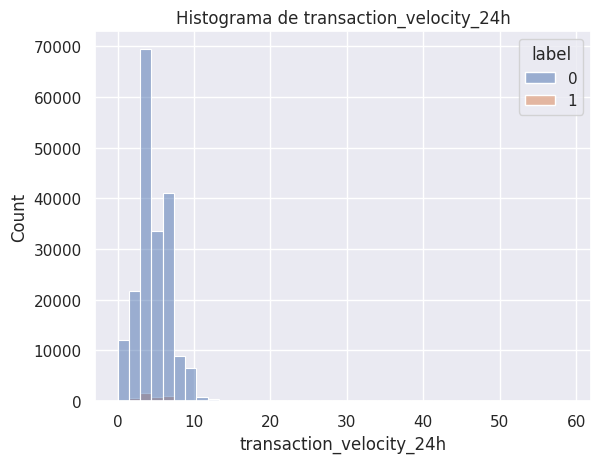

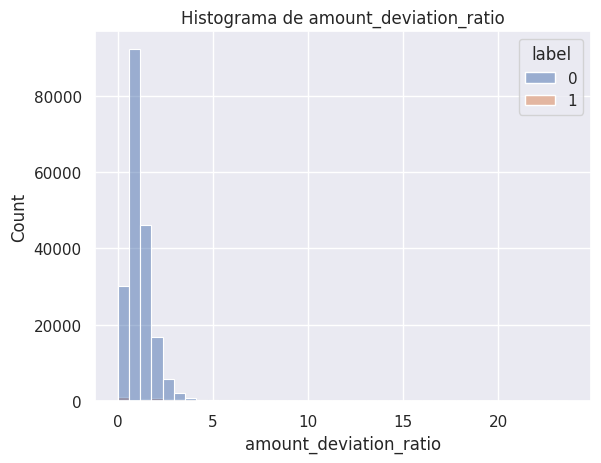

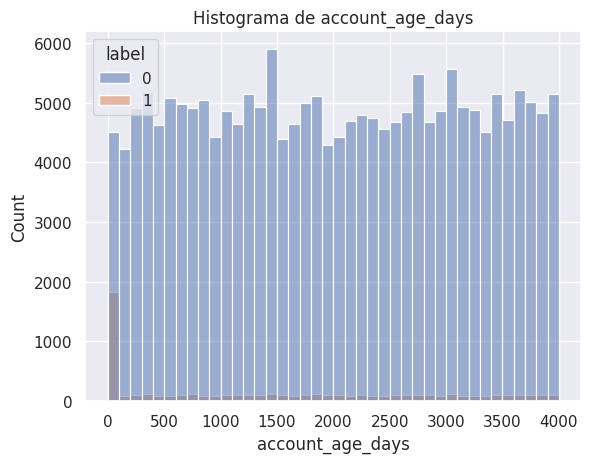

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv('/content/enterprise_fraud_dataset.csv')

# Columnas que vamos a analizar
columnas = [
    'transaction_amount',
    'distance_from_home_km',
    'transaction_velocity_24h',
    'amount_deviation_ratio',
    'account_age_days'
]

# Estilo bonito
sns.set()

# Loop para graficar
for col in columnas:
    plt.figure()

    sns.histplot(data=df, x=col, hue='label', bins=40)

    plt.title(f'Histograma de {col}')
    plt.show()